In [2]:
import pandas as pd
import numpy as np

In [3]:
df_customer = pd.read_csv(r"D:\C Drive\Projects\Python\Kaapi Culture\files\kaapi_culture_customers.csv")
df_order = pd.read_csv(r"D:\C Drive\Projects\Python\Kaapi Culture\files\kaapi_culture_orders.csv")

In [4]:
df_customer['signup_date'] = pd.to_datetime(df_customer['signup_date'])

In [5]:
df_order['order_date'] = pd.to_datetime(df_order['order_date'])

In [6]:
df_order['discount_pct'].isnull().sum()

np.int64(793)

In [7]:
df_order['discount_pct'] = df_order['discount_pct'].fillna(0)

In [8]:
df_order['channel'].value_counts(dropna=False)

channel
Website         11613
Mobile App       9171
Retail Store     4165
Marketplace      2682
NaN               296
Name: count, dtype: int64

In [9]:
df_order['channel'] = df_order['channel'].fillna('Unknown')

In [10]:
df_order['city'].value_counts(dropna=False)

city
Chennai      1590
chennai      1575
jaipur       1535
Ahmedabad    1487
ahmedabad    1412
Jaipur       1405
hyderabad    1169
Hyderabad    1168
pune         1037
Delhi         969
Bengaluru     959
bengaluru     957
Calcutta      953
Pune          946
Kolkata       940
Cochin        929
kolkata       914
kochi         903
Pune          884
delhi         870
Bangalore     867
Kochi         862
New Delhi     860
mumbai        601
MUMBAI        584
 Mumbai       562
Mumbai        555
NaN           434
Name: count, dtype: int64

In [11]:
df_order['city'] = df_order['city'].str.strip().str.title()

In [12]:
df_order['city'].value_counts(dropna=False)

city
Chennai      3165
Jaipur       2940
Ahmedabad    2899
Pune         2867
Hyderabad    2337
Mumbai       2302
Bengaluru    1916
Kolkata      1854
Delhi        1839
Kochi        1765
Calcutta      953
Cochin        929
Bangalore     867
New Delhi     860
NaN           434
Name: count, dtype: int64

In [13]:
df_order['city'] = df_order['city'].fillna('Unknown')

In [14]:
df_order.describe()

,order_date,quantity,unit_price_inr,discount_pct
count,27927,27927.000000,27927.000000,27927.000000
mean,2024-12-14 11:42:23.474057472,1.194901,908.230315,3.652558
min,2023-01-05 00:00:00,-3.000000,149.000000,0.000000
25%,2024-07-27 00:00:00,1.000000,449.000000,0.000000
50%,2025-02-15 00:00:00,1.000000,599.000000,0.000000
75%,2025-06-22 00:00:00,1.000000,1199.000000,0.000000
max,2025-08-31 00:00:00,3.000000,249900.000000,25.000000
std,NaN,0.649212,2253.716940,6.915393


In [15]:
df_order['quantity'] = df_order['quantity'].abs()

In [16]:
df_order.loc[df_order['unit_price_inr'] > 2499, 'unit_price_inr'] /= 100

In [17]:
df_order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27927 entries, 0 to 27926
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   order_id           27927 non-null  object        
 1   customer_id        27927 non-null  object        
 2   order_date         27927 non-null  datetime64[ns]
 3   product_name       27927 non-null  object        
 4   category           27927 non-null  object        
 5   quantity           27927 non-null  int64         
 6   unit_price_inr     27927 non-null  int64         
 7   discount_pct       27927 non-null  float64       
 8   channel            27927 non-null  object        
 9   subscription_type  27927 non-null  object        
 10  city               27927 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(7)
memory usage: 2.3+ MB


In [18]:
df_order['Revenue'] = df_order['unit_price_inr'] * df_order['quantity']

In [19]:
monthly_sales = (df_order.groupby(df_order['order_date'].dt.to_period('M'))['Revenue'].sum())

Monthly Sales Trend 

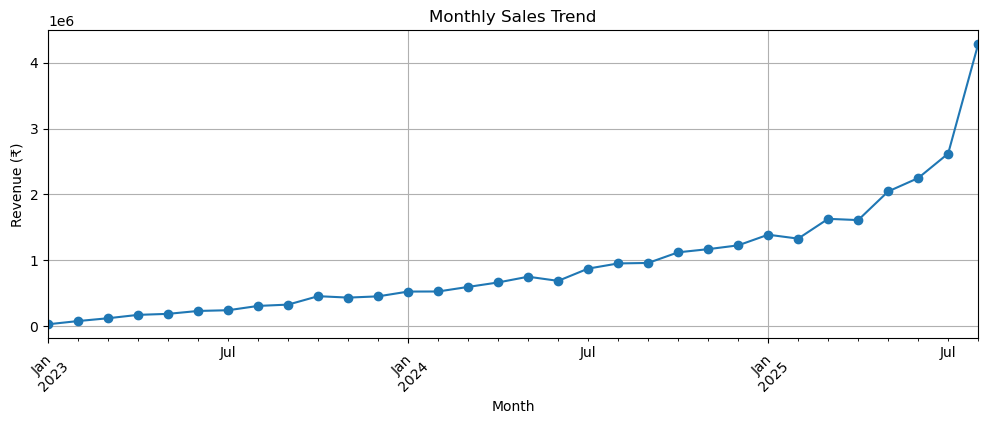

In [20]:
import matplotlib.pyplot as plt

monthly_sales.plot(
    kind='line',
    marker='o',
    figsize=(12, 4)
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

Which product category generates the highest revenue?

In [21]:
category_revenue = df_order.groupby('category')['Revenue'].sum().sort_values(ascending=False)

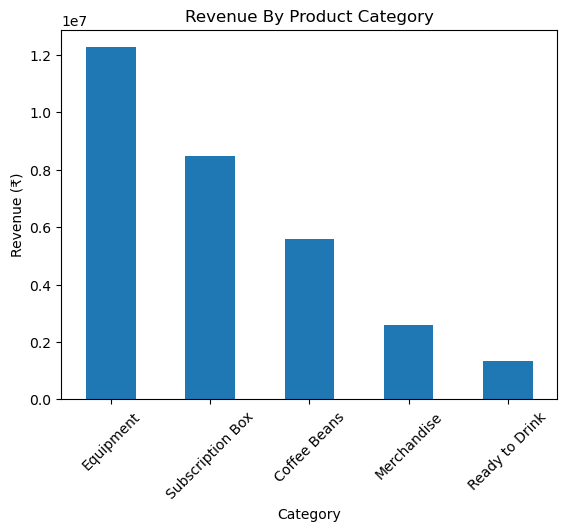

In [22]:
plt.Figure(figsize=(10,6))
category_revenue.plot(kind='bar')
plt.title('Revenue By Product Category')
plt.xlabel('Category')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=45)
plt.show()

Which sales channel generates the most revenue?

In [23]:
channel_revenue = df_order.groupby('channel')['Revenue'].sum().sort_values(ascending=False)

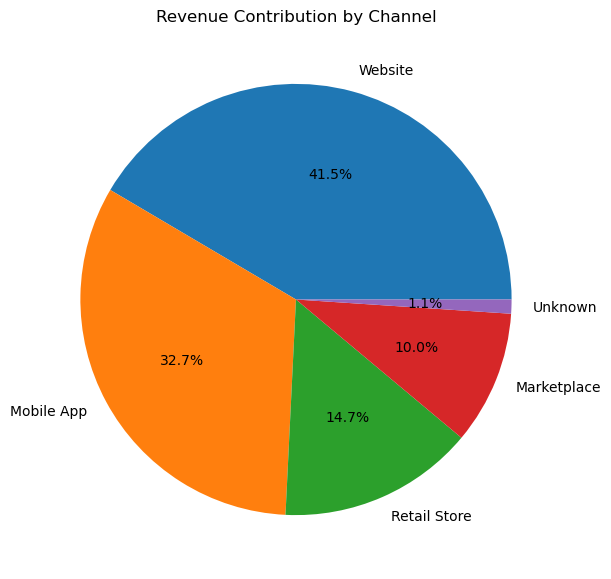

In [32]:
plt.figure(figsize=(7,7))
plt.pie(
    channel_revenue,
    labels=channel_revenue.index,
    autopct='%1.1f%%'
)

plt.title('Revenue Contribution by Channel')
plt.show()

Which cities are the strongest markets?

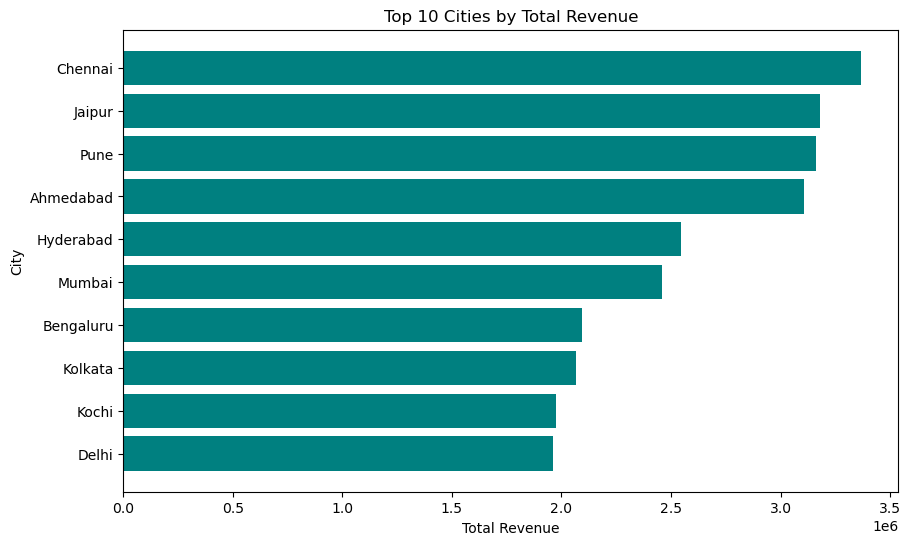

In [ ]:
top_10_cities = df_order.groupby('city')['Revenue'].sum().nlargest(10).reset_index()
top_10_sorted = top_10_cities.sort_values(by='Revenue', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_10_sorted['city'], top_10_sorted['Revenue'], color='teal')
plt.xlabel('Total Revenue')
plt.ylabel('City')
plt.title('Top 10 Cities by Total Revenue')
plt.show()


Does higher discount tend to be associated with higher or lower revenue?

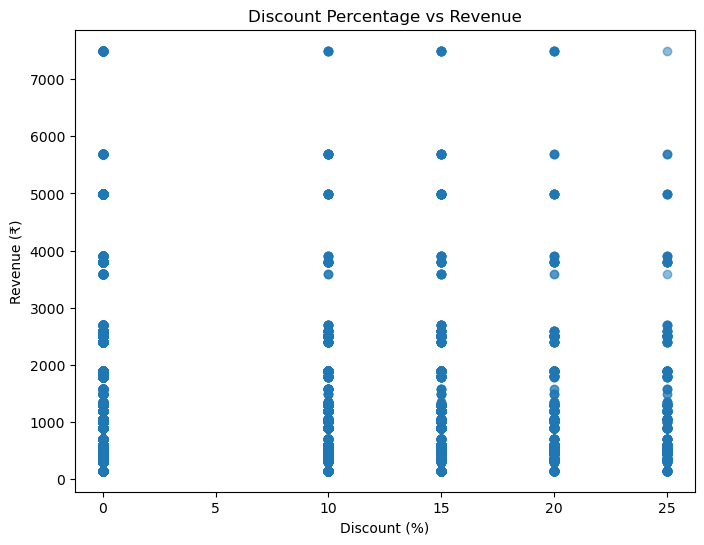

In [41]:
plt.figure(figsize=(8,6))

plt.scatter(
    df_order['discount_pct'],
    df_order['Revenue'],
    alpha=0.5
)

plt.title('Discount Percentage vs Revenue')
plt.xlabel('Discount (%)')
plt.ylabel('Revenue (₹)')
plt.show()

Which customer acquisition channel generates the most revenue?

In [42]:
df = df_order.merge(df_customer, on='customer_id', how='left')

In [43]:
acquisition_revenue = df.groupby('acquisition_channel')['Revenue'].sum().sort_values(ascending=False)

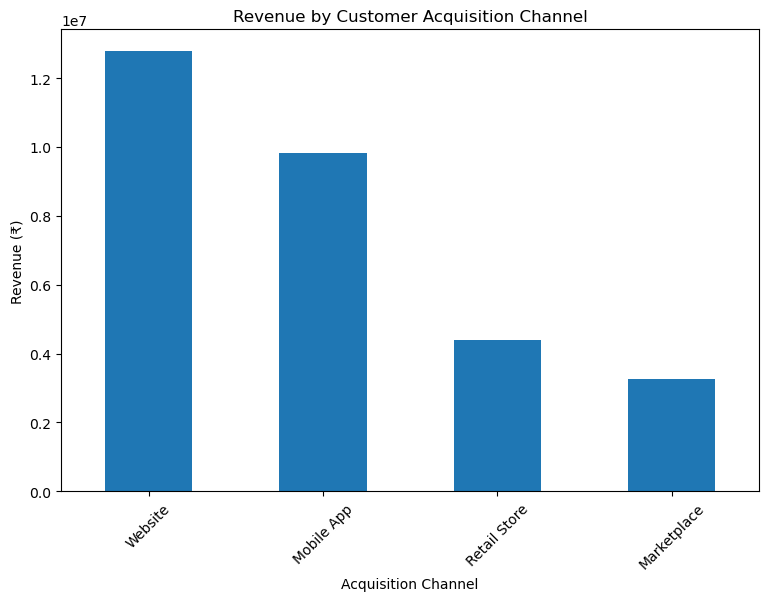

In [44]:
plt.figure(figsize=(9,6))

acquisition_revenue.plot(kind='bar')

plt.title('Revenue by Customer Acquisition Channel')
plt.xlabel('Acquisition Channel')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=45)
plt.show()